In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

In [4]:
# Helpers
def class_counts(y, n_classes=None):
    if n_classes is None:
        n_classes = int(np.max(y)) + 1
    counts = np.zeros(n_classes, dtype=int)
    for label in y:
        counts[label] += 1
    return counts

Gini Impurity: $1-\sum_{k=1}^Kp_k^2$

In [5]:
def gini_impurity(y, n_classes=None):
    if len(y) == 0:
        return 0.0
    counts = class_counts(y, n_classes)
    probs = counts / len(y)
    return 1.0 - np.sum(probs**2)

Entropy: $H(\mathbf y)=-\sum_{k=1}^Kp_k\log_2p_k$

In [6]:
def entropy(y, n_classes=None):
    if len(y) == 0:
        return 0.0
    counts = class_counts(y, n_classes)
    probs = counts / len(y)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

In [7]:
def majority_class(y):
    values, counts = np.unique(y, return_counts=True)
    return values[np.argmax(counts)]

In [8]:
# Tree Node structure
class DecisionTreeNode:
    def __init__(
        self,
        feature_index=None,
        threshold=None,
        left=None,
        right=None,
        *,
        value=None,
        proba=None
    ):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value # predicted class at leaf
        self.proba = proba # class probabilities at leaf

    def is_leaf(self):
        return self.value is not None

At a node, we test all features and all possible thresholds.

For a split into left and right child nodes:
$$
\text{Impurity}_{\text{split}}=\frac{n_L}{n}I(y_L)+\frac{n_R}{n}I(y_R)
$$

In [14]:
# Decision Tree Classifier
class DecisionTreeClassifierScratch:
    def __init__(self, criterion="gini", max_depth=None, min_samples_split=2):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.n_classes_ = None
        self.n_features_ = None
        self.tree_ = None

    def _impurity(self, y):
        if self.criterion == "gini":
            return gini_impurity(y, self.n_classes_)
        elif self.criterion == "entropy":
            return entropy(y, self.n_classes_)
        else:
            raise ValueError("Invalid criterion")

    def _best_split(self, X, y):
        n_samples, n_features = X.shape

        if n_samples < self.min_samples_split:
            return None, None

        best_feature = None
        best_threshold = None
        best_impurity = float('inf')

        for feature_idx in range(n_features):
            feature_values = X[:, feature_idx]
            sorted_indices = np.argsort(feature_values)
            X_sorted = feature_values[sorted_indices]
            y_sorted = y[sorted_indices]

            # candidate threshold: between consecutive distinct values
            for i in range(1, n_samples):
                if X_sorted[i] == X_sorted[i - 1]:
                    continue

                threshold = (X_sorted[i] + X_sorted[i - 1]) / 2.0

                y_left = y_sorted[:i]
                y_right = y_sorted[i:]

                impurity_left = self._impurity(y_left)
                impurity_right = self._impurity(y_right)

                weighted_impurity = (
                    (len(y_left) / n_samples) * impurity_left
                    + (len(y_right) / n_samples) * impurity_right
                )

                if weighted_impurity < best_impurity:
                    best_impurity = weighted_impurity
                    best_feature = feature_idx
                    best_threshold = threshold

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        n_samples = len(y)
        num_unique_labels = len(np.unique(y))

        # class probabilities at this node
        counts = class_counts(y, self.n_classes_)
        proba = counts / np.sum(counts)
        predicted_class = np.argmax(counts)

        # stopping conditions
        if (
            num_unique_labels == 1
            or n_samples < self.min_samples_split
            or (self.max_depth is not None and depth >= self.max_depth)
        ):
            return DecisionTreeNode(value=predicted_class, proba=proba)

        feature_idx, threshold = self._best_split(X, y)

        if feature_idx is None:
            return DecisionTreeNode(value=predicted_class, proba=proba)

        left_mask = X[:, feature_idx] < threshold
        right_mask = ~left_mask

        if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
            return DecisionTreeNode(value=predicted_class, proba=proba)

        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)

        return DecisionTreeNode(
            feature_index=feature_idx,
            threshold=threshold,
            left=left_subtree,
            right=right_subtree
        )

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y, dtype=int)

        self.n_features_ = X.shape[1]
        self.n_classes_ = len(np.unique(y))
        self.tree_ = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature_index] < node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

    def _predict_proba_one(self, x, node):
        if node.is_leaf():
            return node.proba
        if x[node.feature_index] < node.threshold:
            return self._predict_proba_one(x, node.left)
        else:
            return self._predict_proba_one(x, node.right)

    def predict(self, X):
        X = np.asarray(X)
        return np.array([self._predict_one(x, self.tree_) for x in X])

    def predict_proba(self, X):
        X = np.asarray(X)
        return np.array([self._predict_proba_one(x, self.tree_) for x in X])

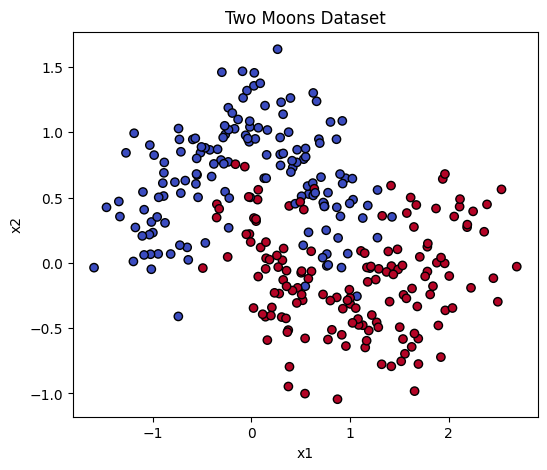

In [15]:
# Create Dataset
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k")
plt.title("Two Moons Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

In [16]:
tree_scratch = DecisionTreeClassifierScratch(criterion="gini", max_depth=4, min_samples_split=5)

tree_scratch.fit(X, y)
y_pred_scratch = tree_scratch.predict(X)

print("Scratch Decision Tree Accuracy:", accuracy_score(y, y_pred_scratch))

Scratch Decision Tree Accuracy: 0.9066666666666666


In [17]:
tree_sklearn = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    min_samples_split=5,
    random_state=42
)

tree_sklearn.fit(X, y)
y_pred_sklearn = tree_sklearn.predict(X)

print("sklearn Decision Tree Accuracy:", accuracy_score(y, y_pred_sklearn))

sklearn Decision Tree Accuracy: 0.9066666666666666


In [18]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

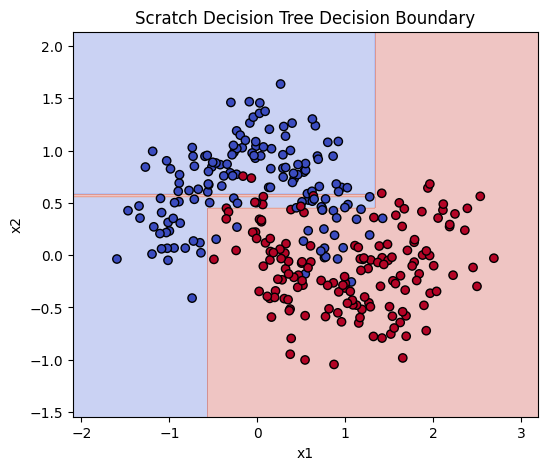

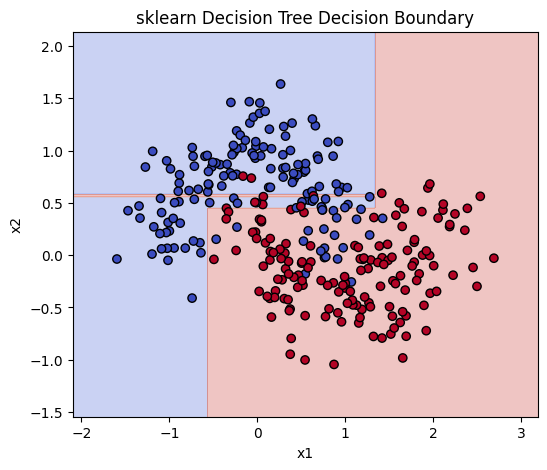

In [19]:
plot_decision_boundary(
    tree_scratch,
    X,
    y,
    "Scratch Decision Tree Decision Boundary"
)

plot_decision_boundary(
    tree_sklearn,
    X,
    y,
    "sklearn Decision Tree Decision Boundary"
)

In [20]:
def plot_probability_surface(model, X, y, class_idx=1, title="Probability Surface"):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    probs = model.predict_proba(grid)[:, class_idx].reshape(xx.shape)

    plt.figure(figsize=(6, 5))
    contour = plt.contourf(xx, yy, probs, levels=30, cmap="viridis")
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolor="k")
    plt.colorbar(contour, label=f"P(class={class_idx})")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

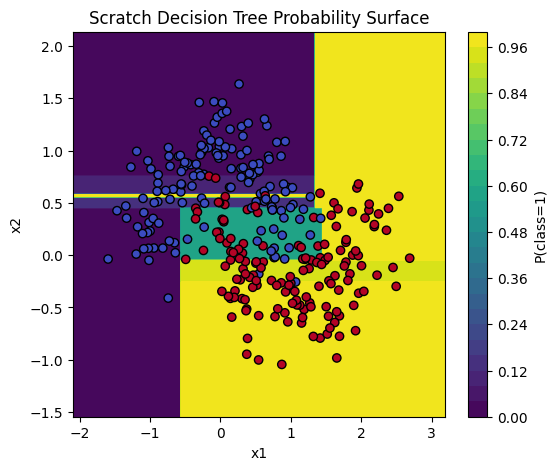

In [21]:
plot_probability_surface(
    tree_scratch,
    X,
    y,
    class_idx=1,
    title="Scratch Decision Tree Probability Surface"
)

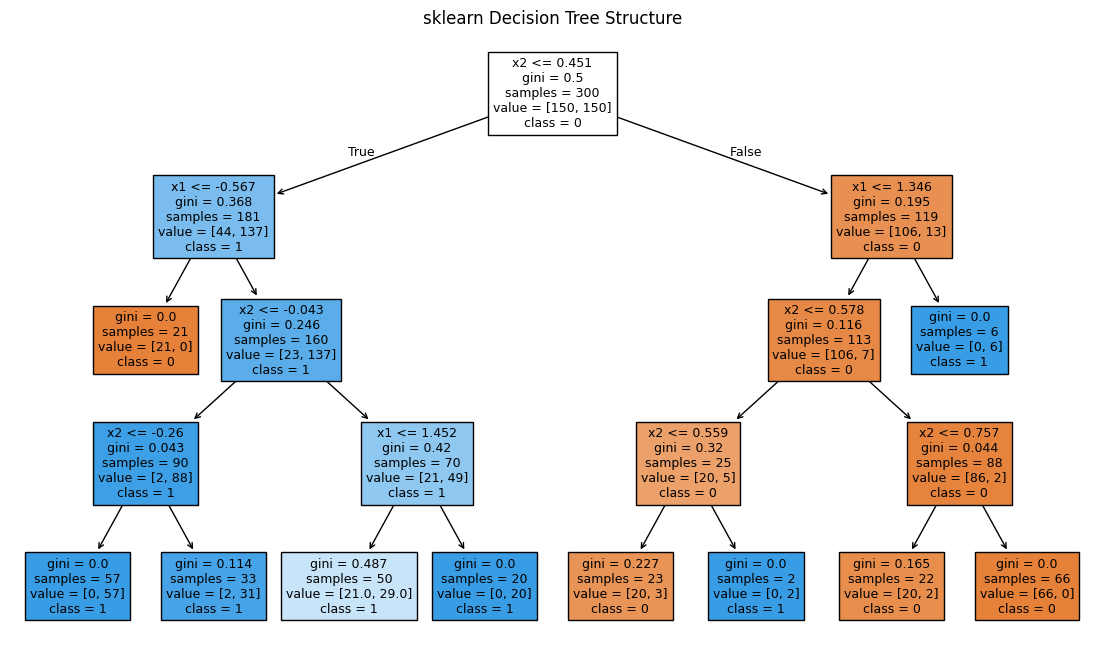

In [22]:
plt.figure(figsize=(14, 8))
plot_tree(
    tree_sklearn,
    filled=True,
    feature_names=["x1", "x2"],
    class_names=["0", "1"]
)
plt.title("sklearn Decision Tree Structure")
plt.show()

In [24]:
def print_tree(node, depth=0):
    indent = "  " * depth
    if node.is_leaf():
        print(f"{indent}Leaf: predict={node.value}, proba={node.proba}")
    else:
        print(f"{indent}if x[{node.feature_index}] < {node.threshold:.4f}:")
        print_tree(node.left, depth + 1)
        print(f"{indent}else:")
        print_tree(node.right, depth + 1)

print_tree(tree_scratch.tree_)

if x[1] < 0.4511:
  if x[0] < -0.5666:
    Leaf: predict=0, proba=[1. 0.]
  else:
    if x[1] < -0.0430:
      if x[1] < -0.2603:
        Leaf: predict=1, proba=[0. 1.]
      else:
        Leaf: predict=1, proba=[0.06060606 0.93939394]
    else:
      if x[0] < 1.4517:
        Leaf: predict=1, proba=[0.42 0.58]
      else:
        Leaf: predict=1, proba=[0. 1.]
else:
  if x[0] < 1.3456:
    if x[1] < 0.5779:
      if x[1] < 0.5589:
        Leaf: predict=0, proba=[0.86956522 0.13043478]
      else:
        Leaf: predict=1, proba=[0. 1.]
    else:
      if x[1] < 0.7568:
        Leaf: predict=0, proba=[0.90909091 0.09090909]
      else:
        Leaf: predict=0, proba=[1. 0.]
  else:
    Leaf: predict=1, proba=[0. 1.]


In [25]:
tree_gini = DecisionTreeClassifierScratch(
    criterion="gini",
    max_depth=4,
    min_samples_split=5
)
tree_entropy = DecisionTreeClassifierScratch(
    criterion="entropy",
    max_depth=4,
    min_samples_split=5
)

tree_gini.fit(X, y)
tree_entropy.fit(X, y)

print("Scratch Gini Accuracy   :", accuracy_score(y, tree_gini.predict(X)))
print("Scratch Entropy Accuracy:", accuracy_score(y, tree_entropy.predict(X)))

Scratch Gini Accuracy   : 0.9066666666666666
Scratch Entropy Accuracy: 0.9


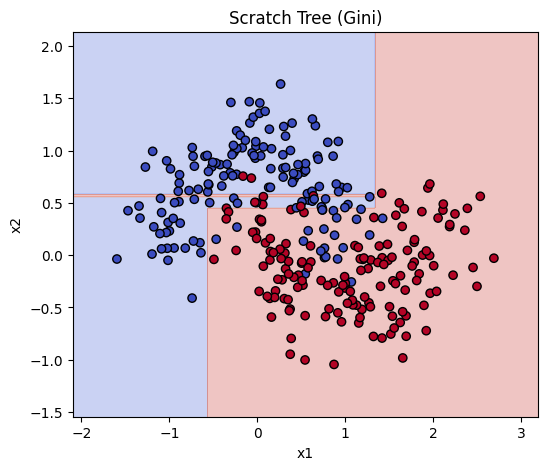

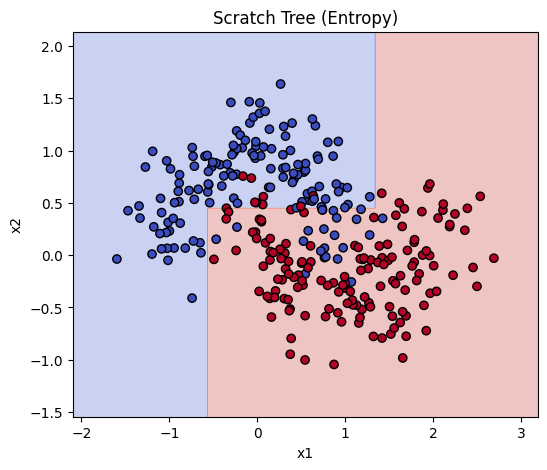

In [26]:
plot_decision_boundary(tree_gini, X, y, "Scratch Tree (Gini)")
plot_decision_boundary(tree_entropy, X, y, "Scratch Tree (Entropy)")